In [47]:

import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats
import importlib
import multi_exp_log
sys.path.append('..')
import plot_settings

import GP

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [44]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [45]:


def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)','soc_cell (1)']
    df.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'soc']

    # Sort by time within each batch
    return df


path = f'ocv_run'

data1 = read_data(path)
data1.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'soc']
data2 = read_data('test_run')
data2.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'soc']
       #'dV', 'dF', 'soc']

display(data1.head())

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_9606/1032301953.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_9606/1032301953.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,u_par,C,t,V,I,F,u,Ue,soc
0,0,0.1,0,4.320851,0.497822,848.709299,0,4.325000,1.000000
1,0,0.1,10,4.314856,0.497822,-213271.116769,0,4.324154,0.999722
2,0,0.1,20,4.312313,0.497822,-427433.775370,0,4.323308,0.999444
3,0,0.1,30,4.310344,0.497822,-641596.433970,0,4.322462,0.999167
4,0,0.1,40,4.308647,0.497822,-855759.092570,0,4.321617,0.998889


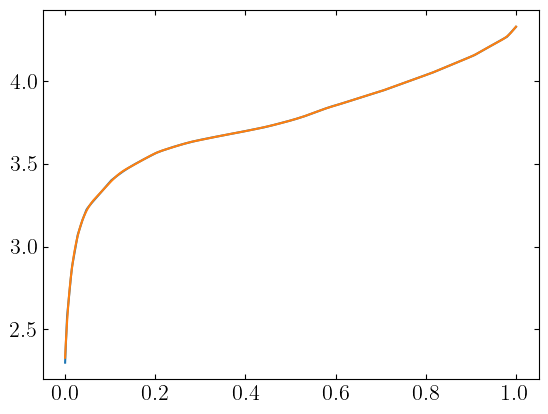

In [ ]:
plt.plot(data1['soc'],data1['Ue'])
plt.plot(data1['soc'],GP.soc_to_Ue(data1['soc'], GP_FIT))
#plt.plot(data2['soc'][:-100] - (0.025 * (1-data2['soc'][:-100])))
#plt.plot(data2['soc'][:-100])